# Input Format (STimage-1K4M — Legacy ST Sample)

- **image**: H&E-stained histopathology image
    - `{id}.png`: Full resolution tissue slide image
- **coord/**: Spot coordinates
    - `{id}_coord.csv`: Pixel positions of each capture spot on the full resolution image
        - `yaxis`: Pixel row position of the spot centroid (vertical)
        - `xaxis`: Pixel column position of the spot centroid (horizontal)
        - `r`: Radius of the spot in pixels
- **gene_exp/**: Gene expression count matrix
    - `{id}_count.csv`: RNA counts per spot per gene
        - Rows: spot IDs in format `{sample}_{row}x{col}` (e.g. `ST_A1_10x13`)
        - Columns: gene names (e.g. `SAMD11`, `NOC2L`, ...) — up to ~15,000 genes
        - Values: integer RNA read counts (sparse — mostly zeros)

# Target Format

- **wsis/**: H&E-stained whole slide images in pyramidal Generic TIFF (or pyramidal Generic BigTIFF if >4.1GB)
- **st/**: Spatial transcriptomics expressions in a scanpy `.h5ad` object
    - **Observations** (`st.adata.obs`)
        - `in_tissue`: Indicator if the observation is within the tissue (`in_tissue` comes from the initial Visium/Xenium run and might not be accurate, prefer the segmentation obtained by `st.segment_tissue()` instead)
        - `pxl_col_in_fullres`: Pixel column position of the patch/spot centroid in the full resolution image
        - `pxl_row_in_fullres`: Pixel row position of the patch/spot centroid in the full resolution image
        - `array_col`: Patch/spot column position in the array
        - `array_row`: Patch/spot row position in the array
        - `n_counts`: Number of counts for each observation
        - `n_genes_by_counts`: Number of genes detected by counts in each observation
        - `log1p_n_genes_by_counts`: Log-transformed number of genes detected by counts
        - `total_counts`: Total counts per observation
        - `log1p_total_counts`: Log-transformed total counts
        - `pct_counts_in_top_50_genes`: Percentage of counts in the top 50 genes
        - `pct_counts_in_top_100_genes`: Percentage of counts in the top 100 genes
        - `pct_counts_in_top_200_genes`: Percentage of counts in the top 200 genes
        - `pct_counts_in_top_500_genes`: Percentage of counts in the top 500 genes
        - `total_counts_mito`: Total mitochondrial counts per observation *(may not be accurate)*
        - `log1p_total_counts_mito`: Log-transformed total mitochondrial counts *(may not be accurate)*
        - `pct_counts_mito`: Percentage of counts that are mitochondrial *(may not be accurate)*
    - **Variables** (`st.adata.var`)
        - `n_cells_by_counts`: Number of cells detected by counts for each variable
        - `mean_counts`: Mean counts per variable
        - `log1p_mean_counts`: Log-transformed mean counts
        - `pct_dropout_by_counts`: Percentage of dropout events by counts
        - `total_counts`: Total counts per variable
        - `log1p_total_counts`: Log-transformed total counts
        - `mito`: Indicator if the gene is mitochondrial
    - **Unstructured** (`st.adata.uns`)
        - `spatial`: Contains a downscaled version of the full resolution image in `st.adata.uns['spatial']['ST']['images']['downscaled_fullres']`
    - **Observation-wise Multidimensional** (`st.adata.obsm`)
        - `spatial`: Pixel coordinates of spots/patches centroids on the full resolution image (first column = x axis, second column = y axis)
- **metadata/**: Metadata
- **spatial_plots/**: Overlay of the WSI with the ST spots
- **thumbnails/**: Downscaled version of the WSI
- **tissue_seg/**: Tissue segmentation masks
    - `{id}.geojson`: Tissue segmentation mask
    - `{id}_vis.jpg`: Visualization of the tissue mask on the downscaled WSI
- **pixel_size_vis/**: Visualization of the pixel size
- **patches/**: 256×256 H&E patches (0.5µm/px) extracted around ST spots in a `.h5` object optimized for deep learning; each patch is matched to the corresponding ST profile (see **st/**) with a barcode
- **patches_vis/**: Visualization of the mask and patches on a downscaled WSI
- **transcripts/**: Individual transcripts aligned to H&E for Xenium samples; read with `pandas.read_parquet`; aligned coordinates in pixels are in columns `['he_x', 'he_y']`
- **cellvit_seg/**: CellViT nuclei segmentation
- **xenium_seg/**: Xenium segmentation on DAPI aligned to H&E

![VisualONE](https://raw.githubusercontent.com/zeptabot/Hest-Assembling-Pipeline/main/VisualONE.png) ![VisualTWO](https://raw.githubusercontent.com/zeptabot/Hest-Assembling-Pipeline/main/VisualTWO.png)

```
╔══════════════════════════════════════════════════════════════════════════════════╗
║                         STimage → HEST TRANSFORMATION                          ║
╚══════════════════════════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────────────────────────┐
│ INPUTS (STimage)                                                                │
├──────────────────┬──────────────────────────┬──────────────────────────────────┤
│ {id}.png         │ {id}_coord.csv           │ {id}_count.csv                   │
│                  │                          │                                  │
│ H&E image        │ spot_id | xaxis | yaxis  │ spot_id | GENE1 | GENE2 | ...    │
│                  │ 10x13   | 1923  | 2622   │ 10x13   |   0   |   1   | ...    │
│                  │ 10x14   | 1926  | 2844   │ 10x14   |   0   |   0   | ...    │
└──────────────────┴──────────────────────────┴──────────────────────────────────┘
         │                      │                           │
         │           coord.rename(xaxis→X, yaxis→Y)        │
         │                      │                           │
         └──────────────────────┴───────────────────────────┘
                                │
                                ▼
                     STReader().read(img_path,
                       raw_counts_path, spot_coord_path)
                                │
                                ▼
          ┌─────────────────────────────────────────────────┐
          │  HESTData object (st)                           │
          │                                                 │
          │  adata.X  ←  count.csv entire matrix           │
          │                                                 │
          │  adata.obs  (one row per spot):                 │
          │   ├─ pxl_col_in_fullres  ←  coord xaxis        │
          │   ├─ pxl_row_in_fullres  ←  coord yaxis        │
          │   ├─ array_row           ←  "10" from 10x13    │
          │   ├─ array_col           ←  "13" from 10x13    │
          │   ├─ in_tissue           ←  hardcode True      │
          │   │                                             │
          │   │  [sc.pp.calculate_qc_metrics() — AUTO]     │
          │   ├─ n_counts            ←  row.sum()          │
          │   ├─ total_counts        ←  row.sum()          │
          │   ├─ log1p_total_counts  ←  log(total+1)       │
          │   ├─ n_genes_by_counts   ←  (row>0).sum()      │
          │   ├─ log1p_n_genes_by_counts ← log(n_genes+1)  │
          │   ├─ pct_counts_in_top_50_genes                 │
          │   ├─ pct_counts_in_top_100_genes  ← sort row   │
          │   ├─ pct_counts_in_top_200_genes    desc, sum  │
          │   ├─ pct_counts_in_top_500_genes    top N /    │
          │   ├─ total_counts_mito   ← row[MT-*].sum()     │
          │   ├─ log1p_total_counts_mito                    │
          │   └─ pct_counts_mito     ← mito/total×100      │
          │                                                 │
          │  adata.var  (one row per gene):                 │
          │   ├─ mito               ← name.startswith(MT-) │
          │   │                                             │
          │   │  [sc.pp.calculate_qc_metrics() — AUTO]     │
          │   ├─ total_counts       ←  col.sum()           │
          │   ├─ log1p_total_counts ←  log(total+1)        │
          │   ├─ mean_counts        ←  col.mean()          │
          │   ├─ log1p_mean_counts  ←  log(mean+1)         │
          │   ├─ n_cells_by_counts  ←  (col>0).sum()       │
          │   └─ pct_dropout_by_counts ← (col==0)/n×100    │
          │                                                 │
          │  adata.uns['spatial']['ST']['images']           │
          │   └─ downscaled_fullres ← png downscaled       │
          │      [via register_downscale_img() — AUTO]      │
          │                                                 │
          │  adata.obsm['spatial']                          │
          │   └─ [[xaxis, yaxis], ...]  ←  coord CSV       │
          └──────────────────────┬──────────────────────────┘
                                 │
       ┌─────────────────────────┼──────────────────────────────────────┐
       │                         │                                      │
       ▼                         ▼                                      ▼
st.save(                 st.save_spatial_plot()           st.segment_tissue()
  save_img=True,                 │                        st.save_tissue_seg_pkl()
  plot_pxl_size=True)            │                                      │
       │                         │                                      │
       ▼                         ▼                                      ▼
┌─────────────────┐   ┌──────────────────┐               ┌─────────────────────┐
│ wsis/           │   │ spatial_plots/   │               │ tissue_seg/         │
│  .tif           │   │  spots overlaid  │               │  {id}.geojson       │
│                 │   │  on downscaled   │               │  {id}_vis.jpg       │
│ st/             │   │  WSI             │               └─────────────────────┘
│  .h5ad          │   └──────────────────┘
│                 │
│ metadata/       │              ▼
│  metrics.json   │   st.dump_patches(
│                 │     target_patch_size=256,
│ thumbnails/     │     target_pixel_size=0.5)
│  .jpeg          │              │
│                 │     ┌────────┴────────┐
│ pixel_size_vis/ │     ▼                ▼
│  .png           │  ┌──────────┐  ┌─────────────┐
└─────────────────┘  │ patches/ │  │ patches_vis/│
                     │  .h5     │  │  _patch_    │
                     │          │  │  vis.png    │
                     └──────────┘  └─────────────┘

┌──────────────────────────────────────────────┐
│ N/A for STimage (Xenium only — skip)         │
│  transcripts/   cellvit_seg/   xenium_seg/   │
└──────────────────────────────────────────────┘
```

In [6]:
# ── Change these two variables per machine ───────────────────────
DATA_DIR     = "/Users/bradzap/Developer/data"
CLEANED_META = "/Users/bradzap/Developer/meta/cleaned_metadata.csv"


In [7]:
import os, shutil, tempfile, pandas as pd
from huggingface_hub import hf_hub_download

TECH_SUFFIX = {
    "ST":       "st",
    "Visium":   "visium",
    "VisiumHD": "visiumhd",
}

def download_slide(slide_name, technology):
    suffix      = TECH_SUFFIX.get(technology, technology.lower())
    stimage_dir = os.path.join(DATA_DIR, f"stimage_{suffix}", slide_name)
    hest_dir    = os.path.join(DATA_DIR, f"hest_{suffix}",    slide_name)
    os.makedirs(stimage_dir, exist_ok=True)
    os.makedirs(hest_dir,    exist_ok=True)

    for file_type, filename in {
        'coord':    f"{slide_name}_coord.csv",
        'gene_exp': f"{slide_name}_count.csv",
        'image':    f"{slide_name}.png",
    }.items():
        dest_path = os.path.join(stimage_dir, filename)
        if os.path.exists(dest_path):
            continue
        try:
            with tempfile.TemporaryDirectory() as tmp:
                src = hf_hub_download(
                    repo_id="jiawennnn/STimage-1K4M",
                    filename=f"{technology}/{file_type}/{filename}",
                    repo_type="dataset",
                    local_dir=tmp,
                )
                shutil.copy(src, dest_path)
        except Exception as e:
            print(f"    ✗ {filename}: {e}")
            return None

    return {'stimage_dir': stimage_dir, 'hest_dir': hest_dir, 'technology': technology}


In [8]:
import os, re
import numpy as np, scanpy as sc, pandas as pd
from PIL import Image
from hest.HESTData import STHESTData
from hest.trident_compat import wsi_factory
from hest.utils import find_pixel_size_from_spot_coords, register_downscale_img, SpotPacking

SPOT_PARAMS = {
    'ST':       {'spot_diameter': 100., 'inter_spot_dist': 200.},
    'Visium':   {'spot_diameter': 55.,  'inter_spot_dist': 100.},
    'VisiumHD': {'spot_diameter': 2.,   'inter_spot_dist': 2.},
}

def convert_slide(slide_name, stimage_dir, hest_dir, technology):
    img_array = np.array(Image.open(os.path.join(stimage_dir, f'{slide_name}.png')).convert('RGB'))
    counts    = pd.read_csv(os.path.join(stimage_dir, f'{slide_name}_count.csv'), index_col=0)
    coord     = pd.read_csv(os.path.join(stimage_dir, f'{slide_name}_coord.csv'), index_col=0)

    common    = counts.index.intersection(coord.index)
    counts, coord = counts.loc[common], coord.loc[common]

    short_ids    = [re.search(r'(\d+x\d+)$', idx).group(1) for idx in counts.index]
    counts.index = coord.index = short_ids

    adata = sc.AnnData(counts)
    adata.obsm['spatial'] = coord[['xaxis', 'yaxis']].values

    my_df = pd.DataFrame(
        adata.obsm['spatial'], index=adata.obs_names,
        columns=['pxl_col_in_fullres', 'pxl_row_in_fullres']
    )
    my_df['array_row'] = [round(float(i.split('x')[0])) for i in my_df.index]
    my_df['array_col'] = [round(float(i.split('x')[1])) for i in my_df.index]

    adata.obs['array_row']          = my_df['array_row'].values
    adata.obs['array_col']          = my_df['array_col'].values
    adata.obs['pxl_col_in_fullres'] = my_df['pxl_col_in_fullres'].values
    adata.obs['pxl_row_in_fullres'] = my_df['pxl_row_in_fullres'].values
    adata.obs['in_tissue']          = True

    pixel_size, spot_estimate_dist = find_pixel_size_from_spot_coords(
        my_df, inter_spot_dist=SPOT_PARAMS[technology]['inter_spot_dist'],
        packing=SpotPacking.GRID_PACKING
    )

    wsi = wsi_factory(img_array, mpp=pixel_size)
    register_downscale_img(adata, wsi, pixel_size,
                           spot_size=SPOT_PARAMS[technology]['spot_diameter'])

    adata.obs.index = [
        i.split('x')[0].zfill(3) + 'x' + i.split('x')[1].zfill(3)
        for i in adata.obs.index
    ]

    adata.var['mito'] = adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mito'], inplace=True)

    meta = {
        'pixel_size_um_embedded':  None,
        'pixel_size_um_estimated': pixel_size,
        'fullres_height':          img_array.shape[0],
        'fullres_width':           img_array.shape[1],
        'spots_under_tissue':      len(adata.obs),
        'spot_estimate_dist':      int(spot_estimate_dist),
        'spot_diameter':           SPOT_PARAMS[technology]['spot_diameter'],
        'inter_spot_dist':         SPOT_PARAMS[technology]['inter_spot_dist'],
    }

    st = STHESTData(adata, img_array, pixel_size, meta)
    st.save(path=hest_dir, save_img=True, pyramidal=True, bigtiff=False, plot_pxl_size=True)
    st.save_spatial_plot(save_path=hest_dir)
    st.segment_tissue(method='otsu')
    st.save_tissue_contours(hest_dir, 'tissue_seg')
    st.save_tissue_vis(hest_dir, 'tissue_seg')
    st.dump_patches(patch_save_dir=hest_dir, name='patches',
                    target_patch_size=256, target_pixel_size=0.5,
                    dump_visualization=True)


[1/946] GSE144239_GSM4284316 (ST)


GSE144239_GSM4284316_coord.csv: 0.00B [00:00, ?B/s]

ST/gene_exp/GSE144239_GSM4284316_count.c(…):   0%|          | 0.00/45.9M [00:00<?, ?B/s]

ST/image/GSE144239_GSM4284316.png:   0%|          | 0.00/11.8M [00:00<?, ?B/s]

saving to pyramidal tiff... can be slow


...

/Users/bradzap/Developer/GitHub/HEST/src/hest/HESTData.py:1657: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(adata, show=False, img_key="downscaled_fullres", color=[key], title=f"in_tissue spots", return_fig=True, **pl_kwargs)
/opt/anaconda3/envs/hest/lib/python3.11/site-packages/trident/segmentation_models/model_zoo/otsu.py:49: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  otsu_masking = sk_morphology.remove_small_objects(otsu_masking, 60)
/opt/anaconda3/envs/hest/lib/python3.11/site-packages/trident/segmentation_models/model_zoo/otsu.py:56: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26

  ✓ done
[3/946] GSE144239_GSM4284318 (ST)


GSE144239_GSM4284318_coord.csv: 0.00B [00:00, ?B/s]

ST/gene_exp/GSE144239_GSM4284318_count.c(…):   0%|          | 0.00/45.9M [00:00<?, ?B/s]

KeyboardInterrupt: 

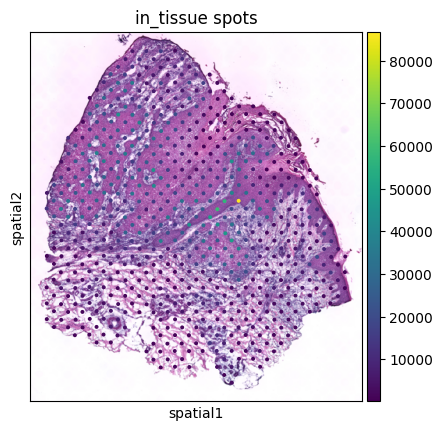

In [9]:
import csv

with open(CLEANED_META, newline="") as f:
    slides = list(csv.DictReader(f))

failed  = []
skipped = 0
done    = 0

for i, row in enumerate(slides):
    slide_name = row['slide']
    technology = row['tech']
    suffix     = TECH_SUFFIX.get(technology, technology.lower())
    hest_dir   = os.path.join(DATA_DIR, f"hest_{suffix}", slide_name)

    if os.path.exists(os.path.join(hest_dir, 'aligned_adata.h5ad')):
        skipped += 1
        continue

    print(f"[{i+1}/{len(slides)}] {slide_name} ({technology})")
    try:
        result = download_slide(slide_name, technology)
        if result is None:
            raise RuntimeError("download failed")
        convert_slide(slide_name, result['stimage_dir'], result['hest_dir'], technology)
        done += 1
        print(f"  ✓ done")
    except Exception as e:
        print(f"  ✗ ERROR: {e}")
        failed.append({'slide': slide_name, 'technology': technology, 'error': str(e)})

print(f"\nFinished: {done} converted, {skipped} skipped (already done), {len(failed)} failed")
if failed:
    print("\nFailed slides:")
    for f in failed:
        print(f"  {f['slide']} ({f['technology']}): {f['error']}")
